# 08. Decision Threshold 최적화
## Threshold Optimization for Fail Detection

## 프로젝트: 반도체 수율 예측 (Semiconductor Yield Prediction)

### 분석 목적

이전 단계에서 기본 XGBoost는 Test Data에서
높은 Accuracy를 기록하였지만 실제 Fail 샘플을 하나도 검출하지 못하였다.

기본 XGBoost 결과:

- Accuracy: 92.99%
- Fail Recall: 0.00%
- True Positive: 0개
- False Negative: 21개
- PR-AUC: 0.1881
- ROC-AUC: 0.7444

Fail Recall은 0이었지만 PR-AUC와 ROC-AUC가
기존 Logistic Regression보다 높게 나타났다.

이는 모델의 예측 확률 자체에는 Pass와 Fail을 구분하는 정보가 존재하지만,
기본 Decision Threshold인 0.5가 현재의 불균형 데이터에
적합하지 않을 가능성을 시사한다.

본 Notebook에서는 Training Data 내부의 Cross Validation 예측 확률만을 이용하여
Decision Threshold를 조정하고 Fail 검출 성능의 변화를 분석한다.

### 주요 분석 목표

1. Training Data에서 Out-of-Fold 예측 확률을 생성한다.
2. Threshold에 따른 Precision / Recall / F2-score 변화를 확인한다.
3. F2-score를 기준으로 Threshold 후보를 선택한다.
4. Test Data는 Threshold 결정에 사용하지 않는다.
5. 선택된 Threshold를 최종 Test Data에 한 번 적용한다.
6. 기본 Threshold 0.5와 Fail 검출 성능을 비교한다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn import set_config
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_predict
)

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

from xgboost import XGBClassifier

set_config(display="text")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## 1. 데이터 준비

이전 모델링 단계와 완전히 동일한 Train/Test Split을 사용한다.

- Test Size: 20%
- `random_state=42`
- `stratify=y`

Threshold 선택 과정에서는 Test Data를 사용하지 않는다.

전체 Training Data 내부에서 5-Fold Stratified Cross Validation을 수행하고,
각 샘플에 대해 해당 샘플을 학습에 사용하지 않은 모델의
Out-of-Fold 예측 확률을 생성한다.

이 확률만을 이용하여 최적 Threshold를 결정한다.

In [2]:
DATA_PATH = Path(
    "../data/processed/uci-secom.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (1567, 592)


In [3]:
feature_cols = [
    col for col in df.columns
    if col.startswith("feature_")
]

X = df[feature_cols].copy()

y = (
    df["Pass/Fail"]
    .replace({
        -1: 0,
        1: 1
    })
    .astype(int)
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(
    y.value_counts()
    .sort_index()
)

X shape: (1567, 590)
y shape: (1567,)

Target distribution:
Pass/Fail
0    1463
1     104
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print(
    f"\nTrain Fail Rate: "
    f"{y_train.mean() * 100:.2f}%"
)

print(
    f"Test Fail Rate : "
    f"{y_test.mean() * 100:.2f}%"
)

X_train: (1253, 590)
X_test : (314, 590)

Train Fail Rate: 6.62%
Test Fail Rate : 6.69%


In [5]:
class FeatureQualityFilter(
    BaseEstimator,
    TransformerMixin
):
    def __init__(
        self,
        missing_threshold=40.0
    ):
        self.missing_threshold = (
            missing_threshold
        )

    def fit(self, X, y=None):

        X = pd.DataFrame(X).copy()

        missing_ratio = (
            X.isna()
            .mean()
            .mul(100)
        )

        high_missing = (
            missing_ratio[
                missing_ratio
                >= self.missing_threshold
            ]
            .index
            .tolist()
        )

        all_missing = [
            col for col in X.columns
            if X[col].isna().all()
        ]

        single_value = [
            col for col in X.columns
            if X[col].nunique(
                dropna=True
            ) == 1
        ]

        self.features_to_remove_ = sorted(
            set(
                high_missing
                + all_missing
                + single_value
            )
        )

        self.features_to_keep_ = [
            col for col in X.columns
            if col
            not in self.features_to_remove_
        ]

        self.feature_names_in_ = np.array(
            X.columns,
            dtype=object
        )

        return self

    def transform(self, X):

        X = pd.DataFrame(
            X,
            columns=self.feature_names_in_
        ).copy()

        return X[
            self.features_to_keep_
        ]

    def get_feature_names_out(
        self,
        input_features=None
    ):
        return np.array(
            self.features_to_keep_,
            dtype=object
        )

## 2. Threshold 최적화 대상 모델

이전 XGBoost 실험에서는 기본 XGBoost가
`scale_pos_weight`를 적용한 모델보다 높은 PR-AUC와 ROC-AUC를 기록하였다.

따라서 본 Threshold Optimization 단계에서는
기본 XGBoost를 분석 대상으로 사용한다.

모델 구조는 이전 단계와 동일하게 유지한다.

1. Feature 품질 필터
2. Median Imputation
3. Base XGBoost

모델 Hyperparameter는 변경하지 않고
Decision Threshold의 영향만 분석한다.

In [6]:
xgb_pipeline = Pipeline([
    (
        "quality_filter",
        FeatureQualityFilter(
            missing_threshold=40
        )
    ),
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "model",
        XGBClassifier(
            objective="binary:logistic",
            random_state=42,
            tree_method="hist",
            n_jobs=-1,
            eval_metric="logloss"
        )
    )
])

print(xgb_pipeline)

Pipeline(steps=[('quality_filter', FeatureQualityFilter(missing_threshold=40)),
                ('imputer', SimpleImputer(strategy='median')),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric='logloss',
                               feature_...None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                  

## 3. Out-of-Fold 예측 확률 생성

Threshold를 Training Data에 과적합하지 않도록
5-Fold Stratified Cross Validation을 이용하여
Out-of-Fold(OOF) 예측 확률을 생성한다.

각 Training 샘플의 확률은
해당 샘플을 학습에 사용하지 않은 모델에서 생성된다.

따라서 전체 Training Data에 모델을 학습한 뒤
동일한 데이터의 확률을 다시 사용하는 것보다
보다 엄밀한 Threshold 선택이 가능하다.

In [7]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [8]:
oof_probabilities = cross_val_predict(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=None
)

oof_fail_prob = (
    oof_probabilities[:, 1]
)

print(
    "OOF probabilities shape:",
    oof_probabilities.shape
)

print(
    "Fail probabilities shape:",
    oof_fail_prob.shape
)

OOF probabilities shape: (1253, 2)
Fail probabilities shape: (1253,)


In [9]:
oof_probability_df = pd.DataFrame({
    "True Label": y_train.values,
    "Fail Probability": oof_fail_prob
})

oof_probability_summary = (
    oof_probability_df
    .groupby("True Label")[
        "Fail Probability"
    ]
    .agg([
        "count",
        "min",
        "mean",
        "median",
        "max"
    ])
)

oof_probability_summary

,count,min,mean,median,max
True Label,,,,,
0,1170,0.000024,0.011835,0.001313,0.748808
1,83,0.000036,0.052897,0.003618,0.804631


## 4. 기본 Threshold 0.5 성능 확인

먼저 XGBoost의 기본 Decision Threshold인 0.5를
OOF 예측 확률에 적용한다.

이를 기준점으로 사용하여
Threshold를 낮췄을 때 Fail Recall과 False Negative가
어떻게 변화하는지 비교한다.

In [10]:
default_threshold = 0.5

oof_pred_default = (
    oof_fail_prob
    >= default_threshold
).astype(int)

print(
    f"OOF Recall @ 0.5: "
    f"{recall_score(y_train, oof_pred_default):.4f}"
)

print(
    f"OOF Precision @ 0.5: "
    f"{precision_score(y_train, oof_pred_default, zero_division=0):.4f}"
)

print(
    f"OOF F2 @ 0.5: "
    f"{fbeta_score(y_train, oof_pred_default, beta=2, zero_division=0):.4f}"
)

print(
    "\nOOF Confusion Matrix @ 0.5:"
)

print(
    confusion_matrix(
        y_train,
        oof_pred_default
    )
)

OOF Recall @ 0.5: 0.0361
OOF Precision @ 0.5: 0.7500
OOF F2 @ 0.5: 0.0446

OOF Confusion Matrix @ 0.5:
[[1169    1]
 [  80    3]]


## 5. Threshold별 Precision / Recall 분석

Decision Threshold를 낮추면 더 많은 샘플을 Fail로 분류하게 된다.

따라서 일반적으로:

- Fail Recall은 증가할 가능성이 있다.
- False Negative는 감소할 가능성이 있다.
- False Positive는 증가할 가능성이 있다.
- Precision은 감소할 수 있다.

본 프로젝트에서는 실제 Fail을 놓치는 문제를 중요하게 보기 때문에
Precision과 Recall을 함께 고려하되,
Recall에 더 높은 가중치를 부여하는 F2-score를
Threshold 선택의 주요 기준으로 사용한다.

In [11]:
precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_train,
        oof_fail_prob
    )
)

print(
    "Number of thresholds:",
    len(thresholds)
)

Number of thresholds: 1253


In [12]:
precision_values[:-1]
recall_values[:-1]

array([1.        , 1.        , 1.        , ..., 0.02409639, 0.01204819,
       0.01204819], shape=(1253,))

In [13]:
precision_at_threshold = (
    precision_values[:-1]
)

recall_at_threshold = (
    recall_values[:-1]
)

beta = 2

f2_values = (
    (1 + beta**2)
    * precision_at_threshold
    * recall_at_threshold
    /
    (
        beta**2
        * precision_at_threshold
        + recall_at_threshold
        + 1e-12
    )
)

threshold_results = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision_at_threshold,
    "Recall": recall_at_threshold,
    "F2": f2_values
})

threshold_results.head()

,Threshold,Precision,Recall,F2
0,0.000024,0.066241,1.0,0.261830
1,0.000026,0.066294,1.0,0.261995
2,0.000030,0.066347,1.0,0.262160
3,0.000033,0.066400,1.0,0.262326
4,0.000034,0.066453,1.0,0.262492


In [14]:
best_threshold_row = (
    threshold_results
    .sort_values(
        "F2",
        ascending=False
    )
    .iloc[0]
)

best_threshold = (
    best_threshold_row[
        "Threshold"
    ]
)

print(
    f"Best threshold: "
    f"{best_threshold:.4f}"
)

print(
    f"OOF Precision: "
    f"{best_threshold_row['Precision']:.4f}"
)

print(
    f"OOF Recall: "
    f"{best_threshold_row['Recall']:.4f}"
)

print(
    f"OOF F2: "
    f"{best_threshold_row['F2']:.4f}"
)

Best threshold: 0.0086
OOF Precision: 0.1533
OOF Recall: 0.4819
OOF F2: 0.3373


In [15]:
top_thresholds = (
    threshold_results
    .sort_values(
        "F2",
        ascending=False
    )
    .head(20)
    .reset_index(drop=True)
)

top_thresholds.round(4)

,Threshold,Precision,Recall,F2
0,0.0086,0.1533,0.4819,0.3373
1,0.0085,0.1527,0.4819,0.3367
2,0.0085,0.1521,0.4819,0.3361
3,0.0085,0.1515,0.4819,0.3356
4,0.0084,0.1509,0.4819,0.3350
5,0.0083,0.1504,0.4819,0.3344
6,0.0083,0.1498,0.4819,0.3339
7,0.0083,0.1493,0.4819,0.3333
8,0.0082,0.1487,0.4819,0.3328
9,0.0082,0.1481,0.4819,0.3322


In [16]:
threshold_diagnostics = []

for threshold in thresholds:

    pred = (
        oof_fail_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = (
        confusion_matrix(
            y_train,
            pred
        ).ravel()
    )

    threshold_diagnostics.append({
        "Threshold": threshold,

        "Precision":
            precision_score(
                y_train,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_train,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_train,
                pred,
                zero_division=0
            ),

        "F2":
            fbeta_score(
                y_train,
                pred,
                beta=2,
                zero_division=0
            ),

        "False Negatives":
            fn,

        "True Positives":
            tp,

        "False Positives":
            fp,

        "True Negatives":
            tn
    })

threshold_diagnostics_df = (
    pd.DataFrame(
        threshold_diagnostics
    )
)

threshold_diagnostics_df.head()

,Threshold,Precision,Recall,F1,F2,False Negatives,True Positives,False Positives,True Negatives
0,0.000024,0.066241,1.0,0.124251,0.261830,0,83,1170,0
1,0.000026,0.066294,1.0,0.124345,0.261995,0,83,1169,1
2,0.000030,0.066347,1.0,0.124438,0.262160,0,83,1168,2
3,0.000033,0.066400,1.0,0.124531,0.262326,0,83,1167,3
4,0.000034,0.066453,1.0,0.124625,0.262492,0,83,1166,4


In [17]:
best_diagnostic_row = (
    threshold_diagnostics_df
    .iloc[
        (
            threshold_diagnostics_df[
                "Threshold"
            ]
            - best_threshold
        )
        .abs()
        .argmin()
    ]
)

best_diagnostic_row

Threshold            0.008612
Precision            0.153257
Recall               0.481928
F1                   0.232558
F2                   0.337268
False Negatives     43.000000
True Positives      40.000000
False Positives    221.000000
True Negatives     949.000000
Name: 992, dtype: float64

## 6. Threshold 변화에 따른 성능 Trade-off

Threshold 최적화의 목적은 단순히 Recall을 최대화하는 것이 아니다.

Threshold를 지나치게 낮추면 거의 모든 샘플을 Fail로 판단하여
Recall은 높아질 수 있지만 False Positive가 급격히 증가할 수 있다.

따라서 Precision, Recall 및 F2-score를 함께 비교하여
Fail 검출 성능과 오탐 간의 균형을 확인한다.

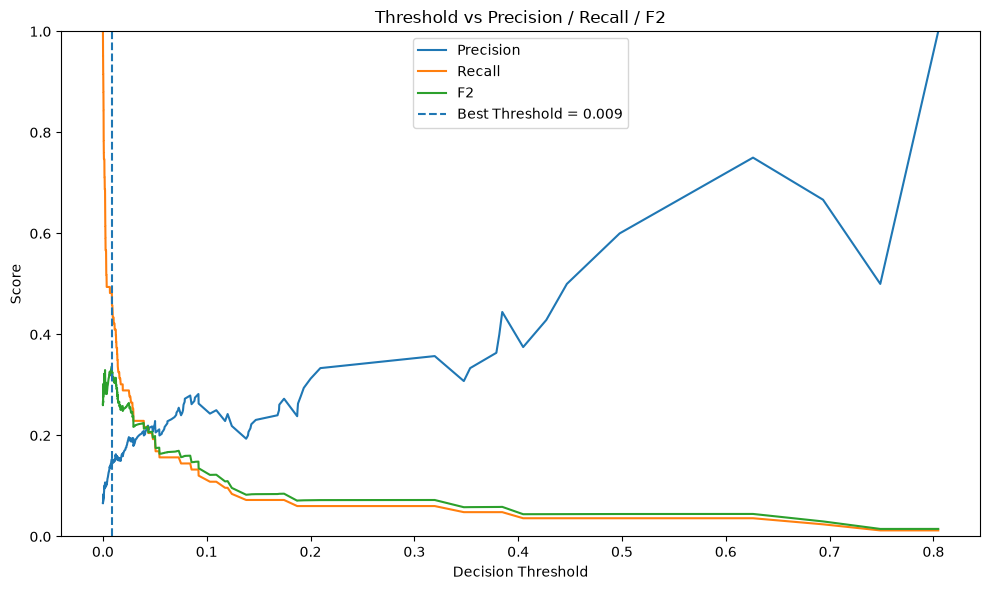

Saved to: ..\results\figures\threshold_metrics_curve.png


In [18]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F2"],
    label="F2"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=(
        f"Best Threshold = "
        f"{best_threshold:.3f}"
    )
)

plt.xlabel(
    "Decision Threshold"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Threshold vs Precision / Recall / F2"
)

plt.ylim(0, 1)
plt.legend()

plt.tight_layout()

THRESHOLD_METRICS_PATH = Path(
    "../results/figures/"
    "threshold_metrics_curve.png"
)

plt.savefig(
    THRESHOLD_METRICS_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved to:",
    THRESHOLD_METRICS_PATH
)

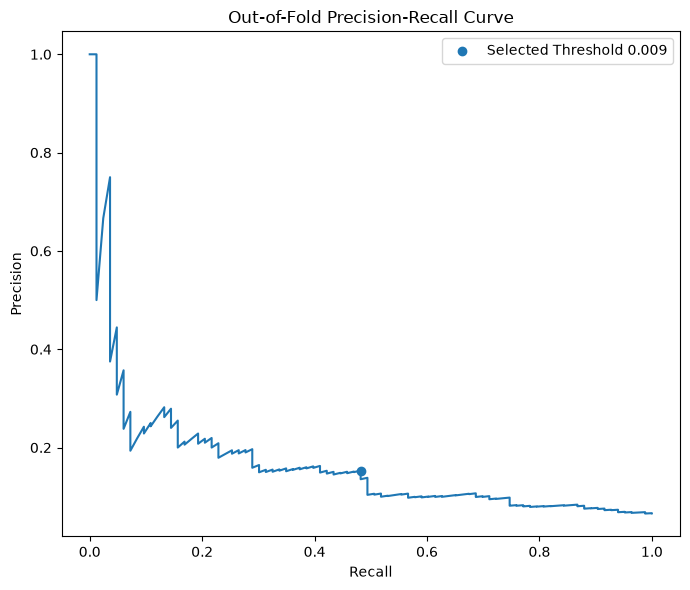

In [19]:
plt.figure(
    figsize=(7, 6)
)

plt.plot(
    recall_values,
    precision_values
)

plt.scatter(
    best_threshold_row["Recall"],
    best_threshold_row["Precision"],
    label=(
        f"Selected Threshold "
        f"{best_threshold:.3f}"
    )
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Out-of-Fold Precision-Recall Curve"
)

plt.legend()

plt.tight_layout()

PR_CURVE_PATH = Path(
    "../results/figures/"
    "oof_precision_recall_curve.png"
)

plt.savefig(
    PR_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
THRESHOLD_RESULT_PATH = Path(
    "../results/metrics/"
    "threshold_cv_results.csv"
)

threshold_diagnostics_df.to_csv(
    THRESHOLD_RESULT_PATH,
    index=False
)

print(
    "Saved to:",
    THRESHOLD_RESULT_PATH
)

print(
    "File exists:",
    THRESHOLD_RESULT_PATH.exists()
)

Saved to: ..\results\metrics\threshold_cv_results.csv
File exists: True


In [21]:
selected_threshold_summary = pd.DataFrame({
    "Metric": [
        "Selected Threshold",
        "OOF Precision",
        "OOF Recall",
        "OOF F2",
        "OOF False Negatives",
        "OOF True Positives",
        "OOF False Positives",
        "OOF True Negatives"
    ],

    "Value": [
        best_threshold,
        best_diagnostic_row[
            "Precision"
        ],
        best_diagnostic_row[
            "Recall"
        ],
        best_diagnostic_row[
            "F2"
        ],
        best_diagnostic_row[
            "False Negatives"
        ],
        best_diagnostic_row[
            "True Positives"
        ],
        best_diagnostic_row[
            "False Positives"
        ],
        best_diagnostic_row[
            "True Negatives"
        ]
    ]
})

selected_threshold_summary

,Metric,Value
0,Selected Threshold,0.008612
1,OOF Precision,0.153257
2,OOF Recall,0.481928
3,OOF F2,0.337268
4,OOF False Negatives,43.000000
5,OOF True Positives,40.000000
6,OOF False Positives,221.000000
7,OOF True Negatives,949.000000


In [22]:
SELECTED_THRESHOLD_PATH = Path(
    "../results/metrics/"
    "selected_threshold_summary.csv"
)

selected_threshold_summary.to_csv(
    SELECTED_THRESHOLD_PATH,
    index=False
)

print(
    "Saved to:",
    SELECTED_THRESHOLD_PATH
)

Saved to: ..\results\metrics\selected_threshold_summary.csv


In [23]:
best_threshold

np.float64(0.008612054400146008)

## 7. 선택된 Threshold의 최종 Test 평가

Threshold는 Training Data 내부의 Out-of-Fold 예측 결과만을 이용하여 결정하였다.

이제 전체 Training Data를 이용하여 XGBoost를 다시 학습하고,
최종 Test Data에 선택된 Threshold를 한 번 적용한다.

Test Data의 결과를 확인한 후 Threshold를 다시 변경하지 않는다.

이를 통해 Test Data가 모델 또는 Threshold 선택 과정에
사용되는 Data Leakage를 방지한다.

In [24]:
final_xgb_pipeline = Pipeline([
    (
        "quality_filter",
        FeatureQualityFilter(
            missing_threshold=40
        )
    ),
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "model",
        XGBClassifier(
            objective="binary:logistic",
            random_state=42,
            tree_method="hist",
            n_jobs=-1,
            eval_metric="logloss"
        )
    )
])

final_xgb_pipeline.fit(
    X_train,
    y_train
)

print(
    "Final XGBoost training completed."
)

Final XGBoost training completed.


In [25]:
test_prob = (
    final_xgb_pipeline
    .predict_proba(
        X_test
    )[:, 1]
)

print(
    "Test probabilities:",
    len(test_prob)
)

Test probabilities: 314


In [26]:
test_pred_default = (
    test_prob >= 0.5
).astype(int)

test_pred_optimized = (
    test_prob >= best_threshold
).astype(int)

In [27]:
default_cm = confusion_matrix(
    y_test,
    test_pred_default
)

print(
    "Default Threshold = 0.5"
)

print(default_cm)

print(
    f"\nRecall: "
    f"{recall_score(y_test, test_pred_default):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test, test_pred_default, zero_division=0):.4f}"
)

print(
    f"F2: "
    f"{fbeta_score(y_test, test_pred_default, beta=2, zero_division=0):.4f}"
)

Default Threshold = 0.5
[[292   1]
 [ 21   0]]

Recall: 0.0000
Precision: 0.0000
F2: 0.0000


In [28]:
optimized_accuracy = accuracy_score(
    y_test,
    test_pred_optimized
)

optimized_precision = precision_score(
    y_test,
    test_pred_optimized,
    zero_division=0
)

optimized_recall = recall_score(
    y_test,
    test_pred_optimized,
    zero_division=0
)

optimized_f1 = f1_score(
    y_test,
    test_pred_optimized,
    zero_division=0
)

optimized_f2 = fbeta_score(
    y_test,
    test_pred_optimized,
    beta=2,
    zero_division=0
)

optimized_pr_auc = average_precision_score(
    y_test,
    test_prob
)

optimized_roc_auc = roc_auc_score(
    y_test,
    test_prob
)

optimized_cm = confusion_matrix(
    y_test,
    test_pred_optimized
)

print(
    f"Selected Threshold: "
    f"{best_threshold:.4f}"
)

print(
    f"Accuracy  : "
    f"{optimized_accuracy:.4f}"
)

print(
    f"Precision : "
    f"{optimized_precision:.4f}"
)

print(
    f"Recall    : "
    f"{optimized_recall:.4f}"
)

print(
    f"F1-score  : "
    f"{optimized_f1:.4f}"
)

print(
    f"F2-score  : "
    f"{optimized_f2:.4f}"
)

print(
    f"PR-AUC    : "
    f"{optimized_pr_auc:.4f}"
)

print(
    f"ROC-AUC   : "
    f"{optimized_roc_auc:.4f}"
)

print(
    "\nConfusion Matrix:"
)

print(
    optimized_cm
)

Selected Threshold: 0.0086
Accuracy  : 0.8217
Precision : 0.1818
Recall    : 0.4762
F1-score  : 0.2632
F2-score  : 0.3597
PR-AUC    : 0.1881
ROC-AUC   : 0.7444

Confusion Matrix:
[[248  45]
 [ 11  10]]


In [29]:
print(
    classification_report(
        y_test,
        test_pred_optimized,
        target_names=[
            "Pass",
            "Fail"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Pass       0.96      0.85      0.90       293
        Fail       0.18      0.48      0.26        21

    accuracy                           0.82       314
   macro avg       0.57      0.66      0.58       314
weighted avg       0.91      0.82      0.86       314



## 8. 기본 Threshold와 최적 Threshold 비교

동일한 XGBoost 모델의 예측 확률을 사용하되,
Decision Threshold만 변경하여 Fail 검출 성능을 비교한다.

따라서 두 결과 간 차이는 모델 자체의 변경이 아니라
확률을 최종 Pass/Fail 클래스로 변환하는 운영 기준의 차이에서 발생한다.

In [30]:
default_tn, default_fp, \
default_fn, default_tp = (
    default_cm.ravel()
)

optimized_tn, optimized_fp, \
optimized_fn, optimized_tp = (
    optimized_cm.ravel()
)

threshold_comparison = pd.DataFrame({
    "Threshold": [
        0.5,
        best_threshold
    ],

    "Model": [
        "Base XGBoost (Default Threshold)",
        "Base XGBoost (Optimized Threshold)"
    ],

    "Accuracy": [
        accuracy_score(
            y_test,
            test_pred_default
        ),
        optimized_accuracy
    ],

    "Precision": [
        precision_score(
            y_test,
            test_pred_default,
            zero_division=0
        ),
        optimized_precision
    ],

    "Recall": [
        recall_score(
            y_test,
            test_pred_default,
            zero_division=0
        ),
        optimized_recall
    ],

    "F1": [
        f1_score(
            y_test,
            test_pred_default,
            zero_division=0
        ),
        optimized_f1
    ],

    "F2": [
        fbeta_score(
            y_test,
            test_pred_default,
            beta=2,
            zero_division=0
        ),
        optimized_f2
    ],

    "PR-AUC": [
        optimized_pr_auc,
        optimized_pr_auc
    ],

    "ROC-AUC": [
        optimized_roc_auc,
        optimized_roc_auc
    ],

    "False Negatives": [
        default_fn,
        optimized_fn
    ],

    "True Positives": [
        default_tp,
        optimized_tp
    ],

    "False Positives": [
        default_fp,
        optimized_fp
    ]
})

threshold_comparison.round(4)

,Threshold,Model,Accuracy,Precision,Recall,F1,F2,PR-AUC,ROC-AUC,False Negatives,True Positives,False Positives
0,0.5000,Base XGBoost (Default Threshold),0.9299,0.0000,0.0000,0.0000,0.0000,0.1881,0.7444,21,0,1
1,0.0086,Base XGBoost (Optimized Threshold),0.8217,0.1818,0.4762,0.2632,0.3597,0.1881,0.7444,11,10,45


In [31]:
FINAL_THRESHOLD_RESULT_PATH = Path(
    "../results/metrics/"
    "threshold_test_comparison.csv"
)

threshold_comparison.to_csv(
    FINAL_THRESHOLD_RESULT_PATH,
    index=False
)

print(
    "Saved to:",
    FINAL_THRESHOLD_RESULT_PATH
)

Saved to: ..\results\metrics\threshold_test_comparison.csv


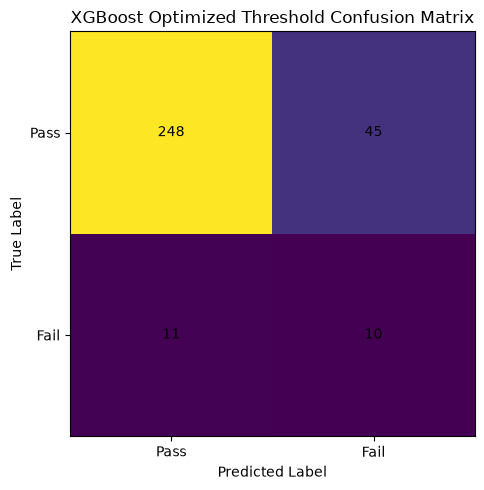

In [32]:
plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    optimized_cm
)

plt.title(
    "XGBoost Optimized Threshold Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.xticks(
    [0, 1],
    ["Pass", "Fail"]
)

plt.yticks(
    [0, 1],
    ["Pass", "Fail"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            optimized_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

OPTIMIZED_CM_PATH = Path(
    "../results/figures/"
    "optimized_threshold_confusion_matrix.png"
)

plt.savefig(
    OPTIMIZED_CM_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

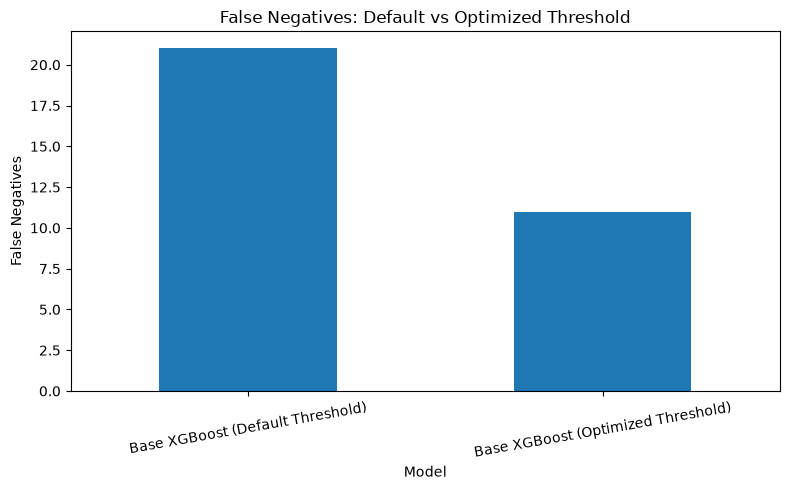

In [33]:
fn_plot_df = (
    threshold_comparison[
        [
            "Model",
            "False Negatives"
        ]
    ]
    .set_index("Model")
)

fn_plot_df.plot(
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.ylabel(
    "False Negatives"
)

plt.title(
    "False Negatives: Default vs Optimized Threshold"
)

plt.xticks(
    rotation=10
)

plt.tight_layout()

THRESHOLD_FN_PATH = Path(
    "../results/figures/"
    "threshold_false_negative_comparison.png"
)

plt.savefig(
    THRESHOLD_FN_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Threshold Optimization 종합 결과

본 단계에서는 XGBoost 모델의 구조와 Hyperparameter를 변경하지 않고,
Decision Threshold 조정만으로 Fail 검출 성능이 어떻게 변화하는지 분석하였다.

Threshold는 Test Data를 이용하여 결정하지 않았다.

Training Data 내부에서 5-Fold Stratified Cross Validation을 수행하고,
각 샘플에 대해 Out-of-Fold 예측 확률을 생성한 뒤
F2-score가 가장 높은 Threshold를 선택하였다.


### 1. Out-of-Fold 예측 확률 분석

Training Data의 OOF 예측 확률을 분석한 결과,
실제 Pass와 Fail 샘플의 평균 Fail Probability는 다음과 같았다.

- Pass 평균: 0.011835
- Fail 평균: 0.052897

중앙값은:

- Pass: 0.001313
- Fail: 0.003618

로 나타났다.

실제 Fail 샘플의 예측 확률이 평균적으로 더 높게 나타났지만,
두 클래스 모두 대부분의 확률이 기본 Decision Threshold인 0.5보다
매우 낮은 영역에 분포하였다.

이는 기존 XGBoost가 Fail을 전혀 검출하지 못한 원인 중 하나가
기본 Threshold 0.5와 관련되어 있을 가능성을 보여준다.


### 2. Training OOF 기반 Threshold 선택

F2-score를 기준으로 선택된 Threshold는 다음과 같다.

**Selected Threshold = 0.0086**

해당 Threshold에서 OOF 성능은:

- Precision: 15.33%
- Recall: 48.19%
- F2-score: 33.73%

로 나타났다.

OOF Confusion Matrix 기준으로:

- True Negative: 949개
- False Positive: 221개
- False Negative: 43개
- True Positive: 40개

를 기록하였다.

Training Data의 실제 Fail 83개 중 40개를
Out-of-Fold 환경에서 검출하였다.


### 3. 최종 Test 성능

Training Data에서 선택한 Threshold 0.0086을
최종 Test Data에 한 번 적용하였다.

Test 성능은 다음과 같다.

- Accuracy: **82.17%**
- Precision: **18.18%**
- Recall: **47.62%**
- F1-score: **26.32%**
- F2-score: **35.97%**
- PR-AUC: **0.1881**
- ROC-AUC: **0.7444**

Confusion Matrix는 다음과 같다.

- True Negative: 248개
- False Positive: 45개
- False Negative: 11개
- True Positive: 10개

즉 실제 Fail 21개 중 10개를 검출하였다.


### 4. 기본 Threshold 0.5와 비교

기본 XGBoost의 Threshold 0.5에서는:

- True Positive: 0개
- False Negative: 21개
- Recall: 0%

로 실제 Fail을 단 하나도 검출하지 못하였다.

Threshold를 0.0086으로 조정한 이후에는:

- True Positive: 10개
- False Negative: 11개
- Recall: 47.62%

로 개선되었다.

따라서 False Negative는 21개에서 11개로 감소하였으며,
기본 Threshold에서 놓쳤던 Fail 중 10개를 추가적으로 검출하였다.


### 5. Precision-Recall Trade-off

Fail 검출 성능의 향상에는 Trade-off가 존재하였다.

Threshold 0.5에서는 False Positive가 1개에 불과했지만,
Threshold 0.0086에서는 False Positive가 45개로 증가하였다.

또한 Accuracy는 약 92.99%에서 82.17%로 감소하였다.

그러나 본 프로젝트의 주요 목적은 높은 Accuracy 자체보다
실제 Fail을 검출하고 False Negative를 줄이는 것이다.

따라서 Accuracy 감소만으로 Threshold 조정이
성능 저하를 의미한다고 판단하지 않는다.

실제 운영 환경에서는 불량 미검출 비용과 정상 제품 오탐 비용을 함께 고려하여
적절한 Threshold를 결정할 필요가 있다.


### 6. Baseline Logistic Regression과 비교

Baseline Logistic Regression은:

- Precision: 12.50%
- Recall: 14.29%
- F2-score: 13.89%
- True Positive: 3개
- False Negative: 18개

를 기록하였다.

Threshold 최적화 XGBoost는:

- Precision: 18.18%
- Recall: 47.62%
- F2-score: 35.97%
- True Positive: 10개
- False Negative: 11개

를 기록하였다.

따라서 단순 선형 Baseline보다
Fail 검출 성능이 크게 향상되었음을 확인하였다.


### 7. PR-AUC와 ROC-AUC

Decision Threshold는 동일한 XGBoost 예측 확률을
최종 클래스에 변환하는 기준만 변경한다.

따라서 Threshold 변경 전후의:

- PR-AUC: 0.1881
- ROC-AUC: 0.7444

는 동일하게 유지된다.

이는 Threshold Optimization이 모델의 확률 순위 학습 능력 자체를
향상시킨 것이 아니라,
이미 학습된 확률 정보를 Fail 검출 목적에 적합하게 활용한 것임을 의미한다.


### 8. 결과 해석

본 실험을 통해 XGBoost가 Fail 정보를 전혀 학습하지 못한 것이 아니라,
기본 Threshold 0.5가 현재 SECOM 불균형 데이터에
적합하지 않았을 가능성을 확인하였다.

Training Data의 Out-of-Fold 확률만을 이용하여 Threshold를 결정한 결과,
최종 Test Data에서도 Fail Recall이 0%에서 47.62%로 향상되었다.

다만 False Positive 증가가 크게 나타났으므로
Threshold 조정만으로 최종 모델을 확정하지 않는다.

또한 선택된 0.0086이라는 값은 현재 모델의 예측 확률에 대한
분류 기준이며 실제 제조 공정상의 절대 불량 확률로 해석하지 않는다.


## 다음 단계: XGBoost Hyperparameter Tuning

다음 단계에서는 Decision Threshold가 아닌
XGBoost 모델 자체의 학습 성능을 개선한다.

Training Data 내부 Cross Validation을 이용하여
다음 Hyperparameter를 탐색한다.

- `n_estimators`
- `max_depth`
- `learning_rate`
- `min_child_weight`
- `subsample`
- `colsample_bytree`
- `scale_pos_weight`

Hyperparameter는 Test Data를 사용하지 않고
Training Data 내부에서 선택한다.

최적화된 XGBoost의 확률 기반 성능(PR-AUC)을 우선 개선한 후,
최종 단계에서 다시 Threshold Optimization을 수행하여
Fail Recall과 False Negative를 평가한다.